### Célula 1: Configuração Global e Carregamento (Design e Tipografia)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


# Configuração de Tipografia (Serif) e Estilo baseados nas diretrizes
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Bitstream Vera Serif', 'serif']
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
sns.set_style("whitegrid")

# Cores harmoniosas (Cores-luz primárias/secundárias ajustadas para estética)
cor_m = '#2C3E50' # Azul escuro/Chumbo
cor_f = '#E74C3C' # Vermelho

# Carregamento e filtro apenas para Jogos de Verão (mantém a linha do tempo coesa)
df = pd.read_csv("athlete_events.csv")
df_summer = df[df['Season'] == 'Summer'].copy()

### Célula 2: 1. Evolução Geral (Masculino vs Feminino) com Espaçamento Proporcional

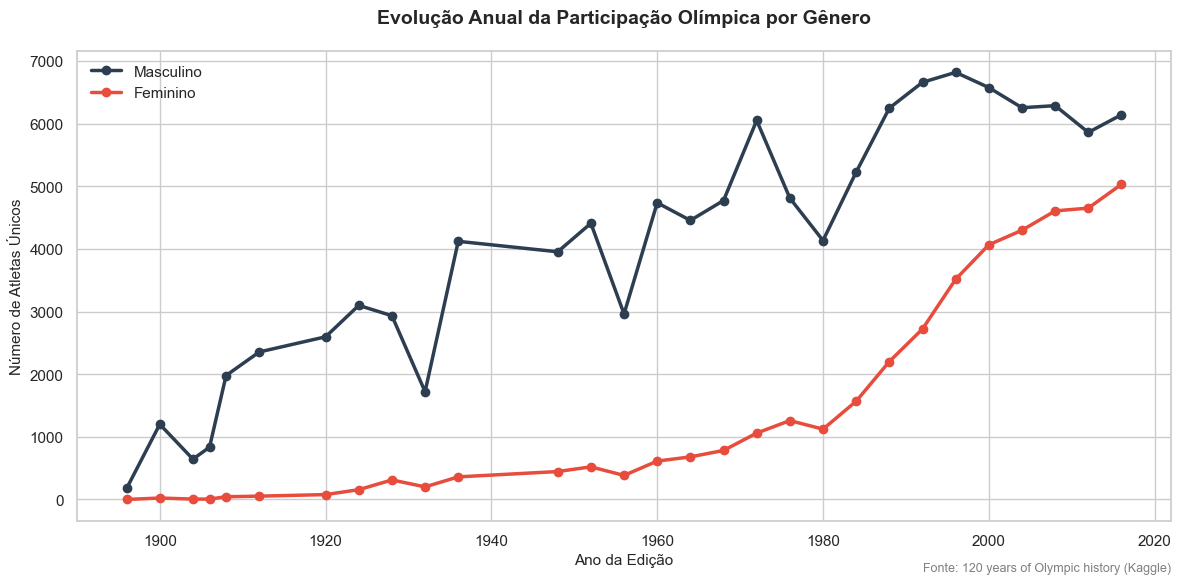

In [10]:
# Agrupamento de IDs únicos por ano e sexo
df_evolucao = df_summer.groupby(['Year', 'Sex'])['ID'].nunique().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

# O eixo X numérico garante o espaçamento proporcional natural
ax.plot(df_evolucao.index, df_evolucao['M'], label='Masculino', color=cor_m, linewidth=2.5, marker='o')
ax.plot(df_evolucao.index, df_evolucao['F'], label='Feminino', color=cor_f, linewidth=2.5, marker='o')

ax.set_title("Evolução Anual da Participação Olímpica por Gênero", pad=20, fontweight='bold')
ax.set_xlabel("Ano da Edição")
ax.set_ylabel("Número de Atletas Únicos")

# Eixo Y limpo (sem decimais)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{int(y)}"))

ax.legend(frameon=False, loc='upper left')
plt.text(1, -0.1, 'Fonte: 120 years of Olympic history (Kaggle)', ha='right', va='center', transform=ax.transAxes, fontsize=9, color='gray')
plt.tight_layout()
plt.show()

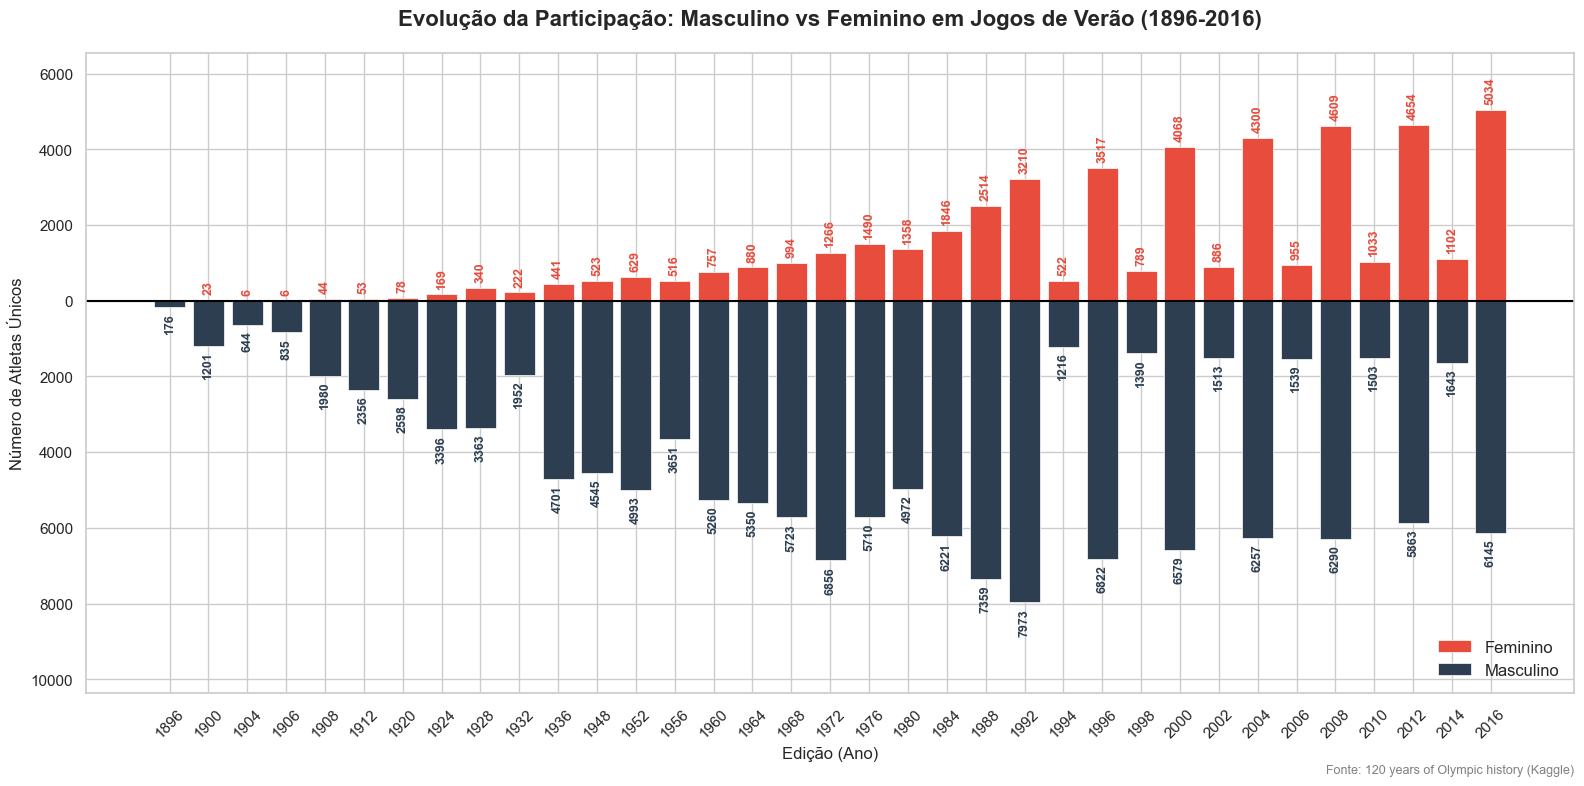

In [23]:
# Configuração de Tipografia baseada nas diretrizes
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Bitstream Vera Serif', 'serif']
sns.set_style("whitegrid")

# Cores
cor_m = '#2C3E50'
cor_f = '#E74C3C'

# 2. Refazer o agrupamento
df_years = df.groupby(['Year', 'Sex'])['ID'].nunique().unstack(fill_value=0).reset_index()
df_years.rename(columns={'Year': 'Ano', 'F': 'Feminino', 'M': 'Masculino'}, inplace=True)

# 3. Preparar posições uniformes para o eixo X (remover espaçamento temporal real)
x_pos = np.arange(len(df_years['Ano']))

# Invertendo o eixo do masculino para formar a parte de baixo do gráfico
masculino_espelhado = df_years['Masculino'] * -1
feminino_espelhado = df_years['Feminino']

# Aumentamos a largura da figura para dar mais respiro
plt.figure(figsize=(16, 8)) 
largura_barra = 0.8

# Plotando as barras usando x_pos em vez dos anos reais
barras_f = plt.bar(x_pos, feminino_espelhado, width=largura_barra, color=cor_f, edgecolor='white', linewidth=0.5, label='Feminino')
barras_m = plt.bar(x_pos, masculino_espelhado, width=largura_barra, color=cor_m, edgecolor='white', linewidth=0.5, label='Masculino')

# Linha divisória central
plt.axhline(0, color='black', linewidth=1.5)

# Textos e Títulos
plt.title("Evolução da Participação: Masculino vs Feminino em Jogos de Verão (1896-2016)", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Edição (Ano)", fontsize=12)
plt.ylabel("Número de Atletas Únicos", fontsize=12)

# Formatador para remover o sinal de "menos" do eixo Y
formatter = ticker.FuncFormatter(lambda y, pos: f"{abs(int(y))}")
plt.gca().yaxis.set_major_formatter(formatter)

# Colocando os rótulos reais dos anos no eixo X com base nas posições sequenciais
plt.xticks(x_pos, df_years['Ano'], rotation=45)

# Adicionando Rótulos de Dados no pico das barras Femininas
for barra in barras_f:
    altura = barra.get_height()
    if altura > 0:
        plt.text(barra.get_x() + barra.get_width()/2., altura + 150, # +150 para descolar da barra
                 f'{int(altura)}', 
                 ha='center', va='bottom', color=cor_f, fontweight='bold', fontsize=9, rotation=90)

# Adicionando Rótulos de Dados no pico das barras Masculinas (que estão para baixo)
for barra in barras_m:
    altura = barra.get_height() # Valor negativo
    if altura < 0:
        plt.text(barra.get_x() + barra.get_width()/2., altura - 150, # -150 para descolar da barra para baixo
                 f'{abs(int(altura))}', 
                 ha='center', va='top', color=cor_m, fontweight='bold', fontsize=9, rotation=90)

# Ajustando o limite do eixo Y para caber os textos (Aumentado em 30%)
plt.ylim(masculino_espelhado.min() * 1.3, feminino_espelhado.max() * 1.3)

# Legenda (sem borda) e Fonte
plt.legend(loc='lower right', frameon=False, fontsize=12)
plt.text(1, -0.12, 'Fonte: 120 years of Olympic history (Kaggle)', ha='right', va='center', transform=plt.gca().transAxes, fontsize=9, color='gray')

plt.tight_layout()
plt.show()

### Célula 3: 2. Os Primeiros Anos (1896-1936) - Modalidades por Sexo

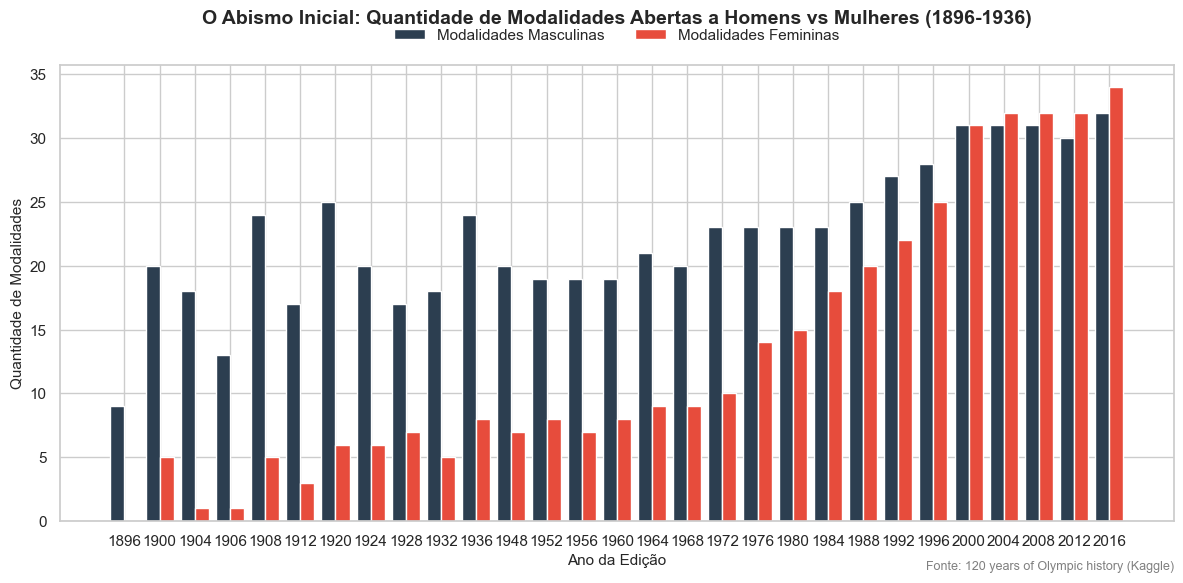

In [43]:
# Foco nos primeiros anos
df_early = df_summer[df_summer['Year'] <= 2016]

# Identificando a quantidade de modalidades diferentes disputadas por M e F
df_modalidades_early = df_early.groupby(['Year', 'Sex'])['Sport'].nunique().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))

# Usando o truque de posições uniformes para garantir o espaçamento padrão
x_pos = np.arange(len(df_modalidades_early.index))
largura_barra = 0.4 # Largura padrão para barras agrupadas

# Desenhando as barras agrupadas
ax.bar(x_pos - largura_barra/2, df_modalidades_early['M'], width=largura_barra, label='Modalidades Masculinas', color=cor_m)
barras_f = ax.bar(x_pos + largura_barra/2, df_modalidades_early['F'], width=largura_barra, label='Modalidades Femininas', color=cor_f)

ax.set_title("O Abismo Inicial: Quantidade de Modalidades Abertas a Homens vs Mulheres (1896-1936)", pad=30, fontweight='bold')
ax.set_xlabel("Ano da Edição")
ax.set_ylabel("Quantidade de Modalidades")

# Ajustando o eixo X para exibir os anos corretamente nas posições uniformes
ax.set_xticks(x_pos)
ax.set_xticklabels(df_modalidades_early.index)

# Legenda e Fonte ajustadas
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)
plt.text(1, -0.1, 'Fonte: 120 years of Olympic history (Kaggle)', ha='right', va='center', transform=ax.transAxes, fontsize=9, color='gray')

plt.tight_layout()
plt.show()

### Célula 5a: Gráfico de Crescimento da Participação Latino-Americana

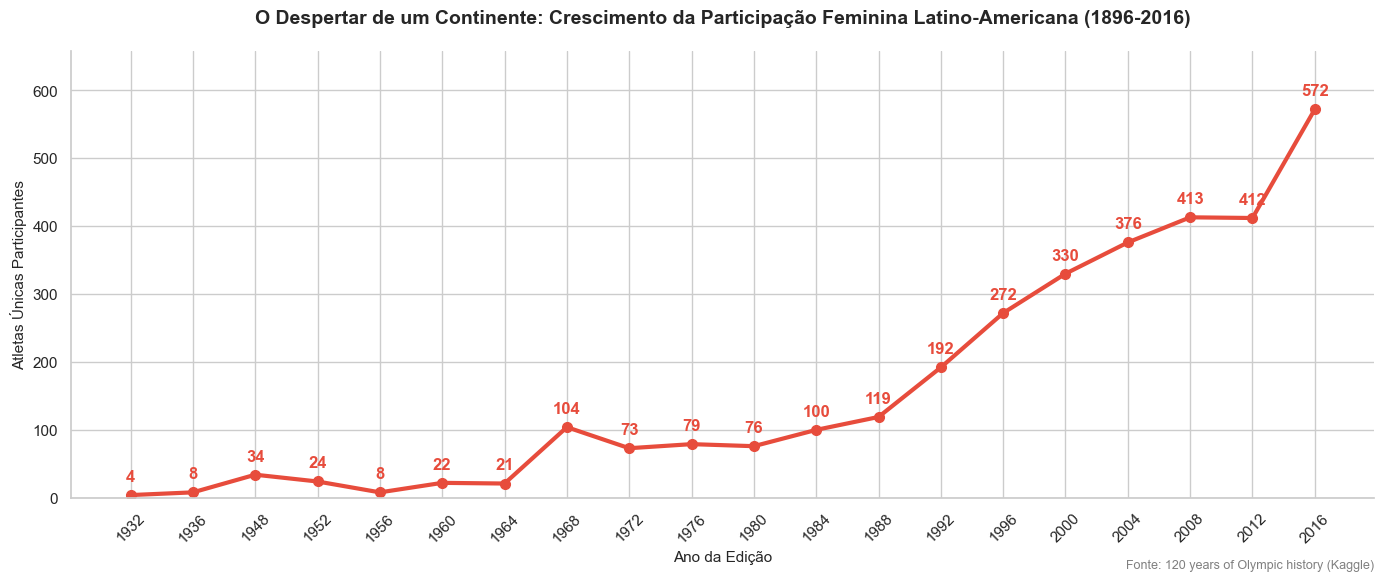

In [48]:
# 1. Definindo os Comitês Olímpicos (NOCs) dos países da América Latina
nocs_latam = ['ARG', 'BOL', 'BRA', 'CHI', 'COL', 'CRC', 'CUB', 'DOM', 'ECU', 
              'ESA', 'GUA', 'HON', 'MEX', 'NCA', 'PAN', 'PAR', 'PER', 'PUR', 'URU', 'VEN']

# 2. Filtrando APENAS mulheres da América Latina que participaram (sem exigir medalha)
df_fem_latam = df_summer[(df_summer['Sex'] == 'F') & 
                         (df_summer['NOC'].isin(nocs_latam))].copy()

# 3. Agrupando atletas únicas por ano para ver o crescimento
df_crescimento_latam = df_fem_latam.groupby('Year')['ID'].nunique()

fig, ax = plt.subplots(figsize=(14, 6))

# SOLUÇÃO: Criar um array sequencial para forçar o espaçamento uniforme
x_pos = np.arange(len(df_crescimento_latam))

# Plotando a linha de crescimento usando as posições sequenciais no eixo X
ax.plot(x_pos, df_crescimento_latam.values, color=cor_f, linewidth=3, marker='o', markersize=7)

# Adicionando rótulos de dados em todos os pontos
for i, (ano, valor) in enumerate(df_crescimento_latam.items()):
    ax.annotate(f'{int(valor)}', (x_pos[i], valor), textcoords="offset points", 
                xytext=(0, 10), ha='center', fontweight='bold', color=cor_f)

# Textos, Títulos e Eixos
ax.set_title("O Despertar de um Continente: Crescimento da Participação Feminina Latino-Americana (1896-2016)", pad=20, fontweight='bold')
ax.set_xlabel("Ano da Edição")
ax.set_ylabel("Atletas Únicas Participantes")

# Ajustando o limite do eixo Y para os rótulos não cortarem
ax.set_ylim(0, df_crescimento_latam.max() * 1.15)

# Garantindo que os anos fiquem visíveis no eixo X (Trocando os números sequenciais pelos anos)
ax.set_xticks(x_pos)
ax.set_xticklabels(df_crescimento_latam.index, rotation=45)

# Limpando bordas (Design clean)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adicionando a fonte
plt.text(1, -0.15, 'Fonte: 120 years of Olympic history (Kaggle)', ha='right', va='center', transform=ax.transAxes, fontsize=9, color='gray')

plt.tight_layout()
plt.show()

### Célula 5b: As 10 Primeiras Atletas Latino-Americanas (Tabela)

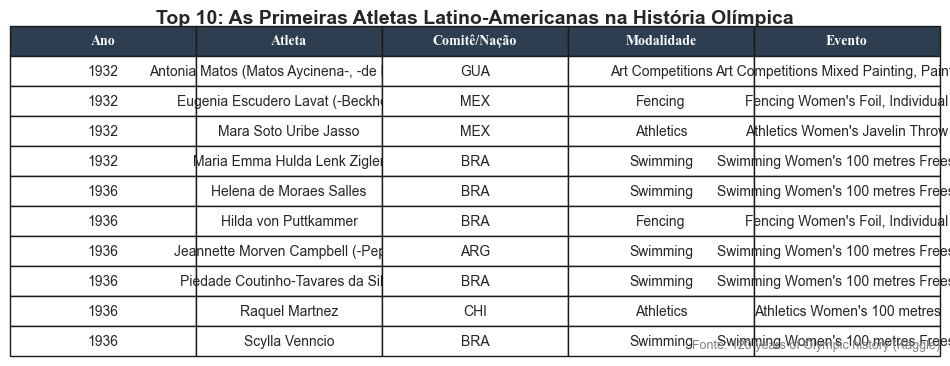

In [36]:
# 1. Ordenando pelo ano (e pelo nome) para pegar as primeiras participações históricas
# O drop_duplicates garante que pegamos apenas a primeira vez que a atleta apareceu
df_pioneiras = df_fem_latam.sort_values(['Year', 'Name']).drop_duplicates(subset=['Name']).head(10)

# Selecionando e renomeando as colunas
df_pioneiras = df_pioneiras[['Year', 'Name', 'NOC', 'Sport', 'Event']]
df_pioneiras.columns = ['Ano', 'Atleta', 'Comitê/Nação', 'Modalidade', 'Evento']

# 2. Criando a visualização em Tabela
fig, ax = plt.subplots(figsize=(12, 4)) # Largura ajustada para o texto dos eventos
ax.axis('off')

tabela = ax.table(cellText=df_pioneiras.values, colLabels=df_pioneiras.columns, cellLoc='center', loc='center')
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1, 1.8)

# Estilização do cabeçalho da tabela
for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_facecolor(cor_m)
        cell.set_text_props(color='w', fontweight='bold', family='serif')

ax.set_title("Top 10: As Primeiras Atletas Latino-Americanas na História Olímpica", fontweight='bold', pad=10)
plt.text(1, 0, 'Fonte: 120 years of Olympic history (Kaggle)', ha='right', va='center', transform=ax.transAxes, fontsize=9, color='gray')
plt.show()

### Célula 6: 5. Crescimento da Participação (Identificação de Saltos)

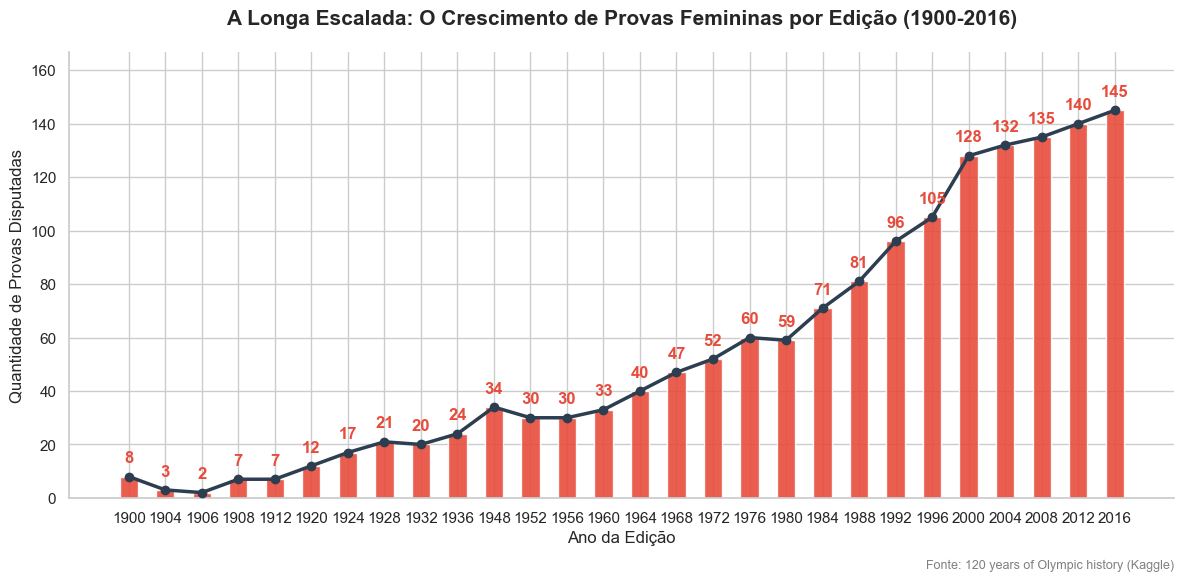

In [40]:
# 1. Filtrar as provas femininas nos Jogos de Verão (Eventos únicos)
df_fem_events = df_summer[df_summer['Sex'] == 'F'].groupby('Year')['Event'].nunique().reset_index()

# 2. Selecionar os anos-chave que contam a história da "Longa Escalada" conforme a referência
df_escalada = df_fem_events.set_index('Year')

fig, ax = plt.subplots(figsize=(12, 6))

# Definindo posições uniformes para o eixo X (para as barras ficarem lado a lado de forma limpa)
x_pos = np.arange(len(df_escalada.index))

# Gráfico de Barras (Quantidade de Provas)
ax.bar(x_pos, df_escalada['Event'], width=0.5, color=cor_f, alpha=0.9, label='Provas Femininas')

# Gráfico de Linha (Acompanhando o crescimento por cima das barras, como na imagem)
ax.plot(x_pos, df_escalada['Event'], color=cor_m, marker='o', linewidth=2.5, zorder=3)

# Adicionando rótulos de dados exatos no topo das barras
for i, valor in enumerate(df_escalada['Event']):
    ax.annotate(f'{int(valor)}', (x_pos[i], valor), textcoords="offset points", 
                xytext=(0, 10), ha='center', fontweight='bold', color=cor_f, fontsize=12)

# Textos e Títulos
ax.set_title("A Longa Escalada: O Crescimento de Provas Femininas por Edição (1900-2016)", pad=20, fontweight='bold', fontsize=15)
ax.set_xlabel("Ano da Edição", fontsize=12)
ax.set_ylabel("Quantidade de Provas Disputadas", fontsize=12)

# Arrumando o eixo X para mostrar apenas os anos-chave
ax.set_xticks(x_pos)
ax.set_xticklabels(df_escalada.index)

# Aumentando o limite Y para o rótulo da última barra não cortar
ax.set_ylim(0, df_escalada['Event'].max() * 1.15)

# Limpando as bordas para manter o design elegante
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Fonte
plt.text(1, -0.15, 'Fonte: 120 years of Olympic history (Kaggle)', ha='right', va='center', transform=ax.transAxes, fontsize=9, color='gray')

plt.tight_layout()
plt.show()

### Célula 7: 6. Mapa de Calor (Heatmap) - Participação Feminina por Modalidade (Sim/Não)

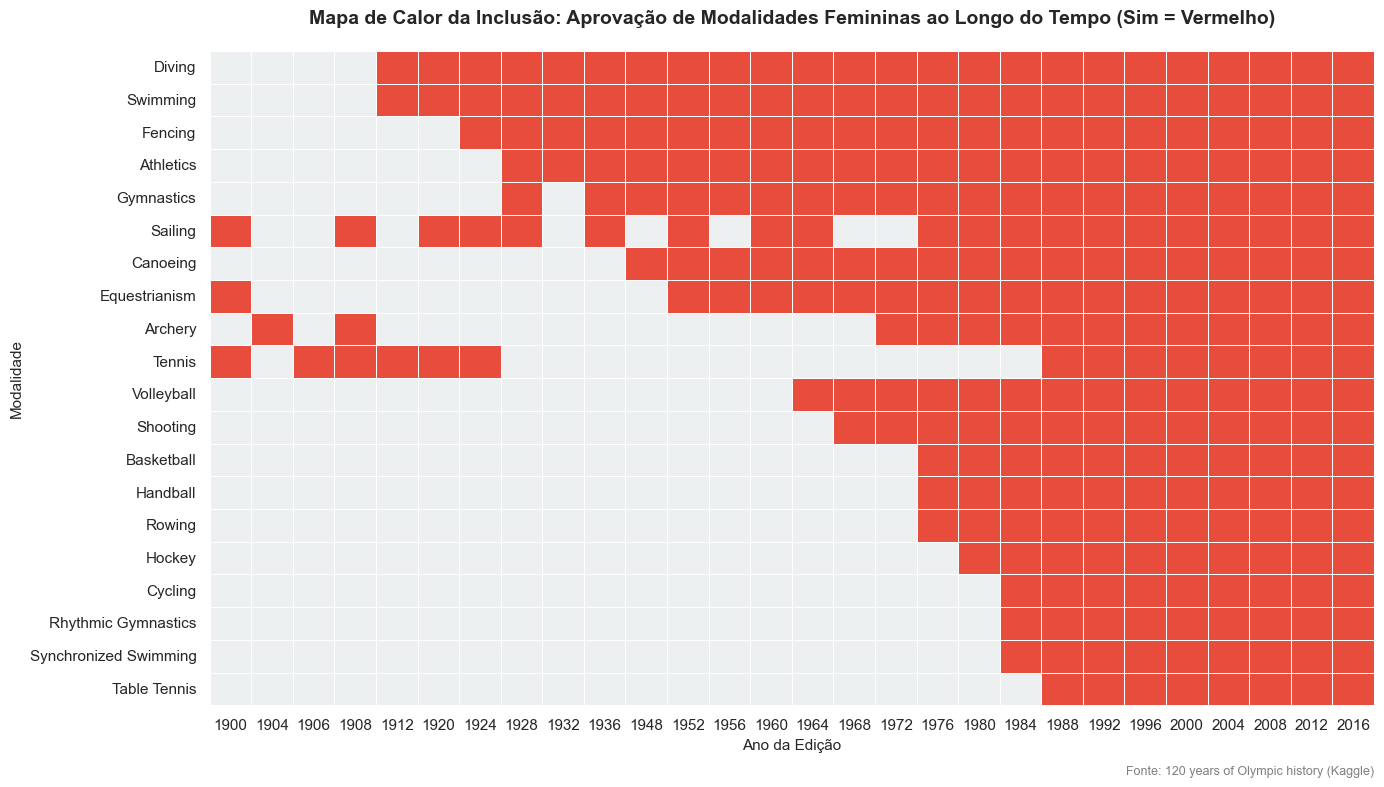

In [16]:
# Criando uma matriz de Ano x Esporte onde 1 = Teve mulher participando, 0 = Nenhuma mulher
df_fem = df_summer[df_summer['Sex'] == 'F']

# Abordagem vetorizada (mais moderna e rápida que o antigo applymap)
# Se o valor for maior que 0, vira True. O .astype(int) transforma True em 1 e False em 0.
heatmap_data = (pd.crosstab(df_fem['Sport'], df_fem['Year']) > 0).astype(int)

# Filtrando os 20 esportes mais consistentes para a visualização não ficar ilegível
top_esportes_heatmap = heatmap_data.sum(axis=1).nlargest(20).index
heatmap_data = heatmap_data.loc[top_esportes_heatmap]

fig, ax = plt.subplots(figsize=(14, 8))

# Usando um colormap binário simples (Cinza claro para 0, Vermelho para 1)
cmap = sns.color_palette(["#ecf0f1", cor_f])

sns.heatmap(heatmap_data, cmap=cmap, cbar=False, linewidths=0.5, linecolor='white', ax=ax)

ax.set_title("Mapa de Calor da Inclusão: Aprovação de Modalidades Femininas ao Longo do Tempo (Sim = Vermelho)", pad=20, fontweight='bold')
ax.set_xlabel("Ano da Edição")
ax.set_ylabel("Modalidade")

# Adicionando a fonte conforme os padrões de design
plt.text(1, -0.1, 'Fonte: 120 years of Olympic history (Kaggle)', ha='right', va='center', transform=ax.transAxes, fontsize=9, color='gray')

plt.tight_layout()
plt.show()

### Célula 8: 8. O Efeito de Concentração (Distribuição na Última Edição - Rio 2016)

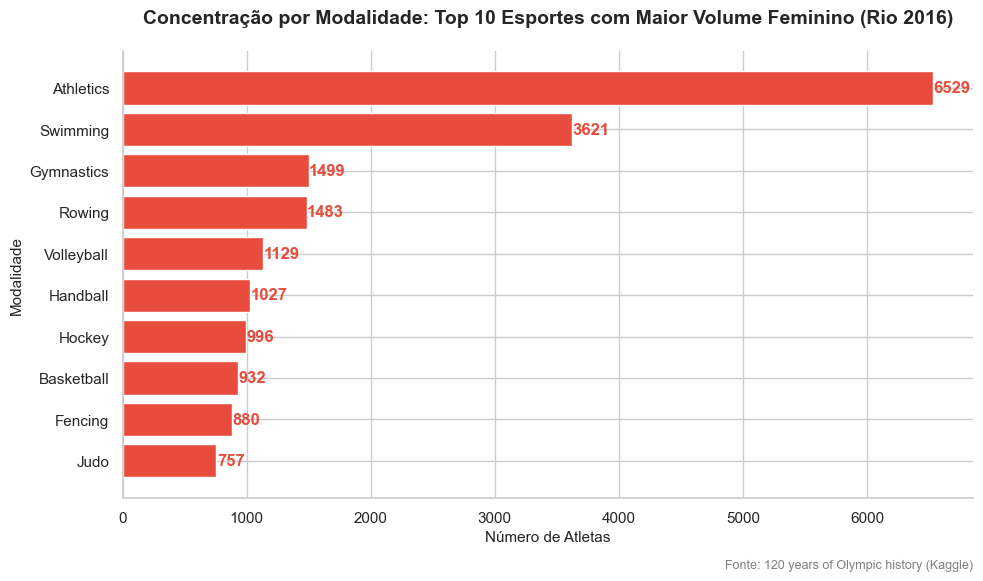

In [44]:
# Dados de 2016
df_f = df_summer[(df_summer['Sex'] == 'F')]
sports_2016 = df_f.groupby('Sport')['ID'].nunique().sort_values(ascending=True)

# Pegando os 10 maiores esportes
top_10_2016 = sports_2016.tail(10)

fig, ax = plt.subplots(figsize=(10, 6))

# Gráfico de barras horizontais, muito melhor para exibir nomes longos que gráficos de pizza
barras = ax.barh(top_10_2016.index, top_10_2016.values, color=cor_f)

# Adicionando rótulos de dados no final de cada barra
for barra in barras:
    ax.text(barra.get_width() + 5, barra.get_y() + barra.get_height()/2, 
            f'{int(barra.get_width())}', 
            va='center', ha='left', color=cor_f, fontweight='bold')

ax.set_title("Concentração por Modalidade: Top 10 Esportes com Maior Volume Feminino (Rio 2016)", pad=20, fontweight='bold')
ax.set_xlabel("Número de Atletas")
ax.set_ylabel("Modalidade")

# Removendo bordas superior e direita para um design mais limpo
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.text(1, -0.15, 'Fonte: 120 years of Olympic history (Kaggle)', ha='right', va='center', transform=ax.transAxes, fontsize=9, color='gray')
plt.tight_layout()
plt.show()

### O Clímax Geopolítico (Top 10 Países com Mais Medalhas Femininas)

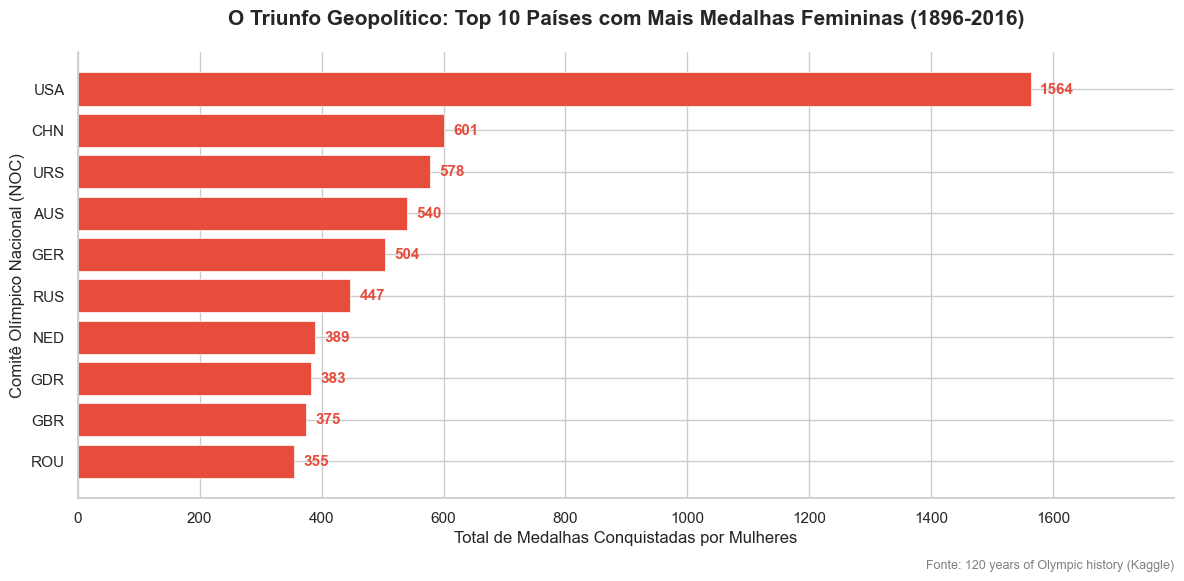

In [46]:
# 1. Filtrando apenas atletas femininas que ganharam alguma medalha (Ouro, Prata ou Bronze) nos Jogos de Verão
df_medalhas_f = df_summer[(df_summer['Sex'] == 'F') & (df_summer['Medal'].notna())]

# 2. Contando o total de medalhas por Comitê Olímpico Nacional (NOC) e pegando os 10 maiores
top10_paises = df_medalhas_f['NOC'].value_counts().nlargest(10)

# 3. Invertendo a ordem para que o país com mais medalhas fique no topo do gráfico
top10_paises = top10_paises.iloc[::-1]

fig, ax = plt.subplots(figsize=(12, 6))

# Desenhando o gráfico de barras horizontais (ideal para rankings)
barras = ax.barh(top10_paises.index, top10_paises.values, color=cor_f, edgecolor='white', linewidth=0.5)

# Adicionando os rótulos de dados exatos ao final de cada barra
for barra in barras:
    ax.text(barra.get_width() + 15, barra.get_y() + barra.get_height()/2, 
            f'{int(barra.get_width())}', 
            va='center', ha='left', color=cor_f, fontweight='bold', fontsize=11)

# Textos e Títulos
ax.set_title("O Triunfo Geopolítico: Top 10 Países com Mais Medalhas Femininas (1896-2016)", pad=20, fontweight='bold', fontsize=15)
ax.set_xlabel("Total de Medalhas Conquistadas por Mulheres", fontsize=12)
ax.set_ylabel("Comitê Olímpico Nacional (NOC)", fontsize=12)

# Ajustando o limite do eixo X para o rótulo da maior barra não ser cortado
ax.set_xlim(0, top10_paises.max() * 1.15)

# Limpeza visual (removendo bordas desnecessárias)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Fonte
plt.text(1, -0.15, 'Fonte: 120 years of Olympic history (Kaggle)', ha='right', va='center', transform=ax.transAxes, fontsize=9, color='gray')

plt.tight_layout()
plt.show()